<a href="https://colab.research.google.com/github/Ansarss/Ai_learning_experiments/blob/main/Image_Classification_with_Convolutional_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prasunroy/natural-images")

print("Path to dataset files:", path)

100%|██████████| 342M/342M [00:02<00:00, 126MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/prasunroy/natural-images/versions/1


In [2]:
import os

print(os.listdir(path))

['data', 'natural_images']


In [3]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = ' ' * 4 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")

1/
    data/
        natural_images/
            person/
                person_0731.jpg
                person_0480.jpg
                person_0166.jpg
                person_0096.jpg
                person_0972.jpg
            cat/
                cat_0839.jpg
                cat_0200.jpg
                cat_0223.jpg
                cat_0579.jpg
                cat_0474.jpg
            car/
                car_0414.jpg
                car_0064.jpg
                car_0868.jpg
                car_0784.jpg
                car_0268.jpg
            fruit/
                fruit_0085.jpg
                fruit_0881.jpg
                fruit_0376.jpg
                fruit_0681.jpg
                fruit_0125.jpg
            airplane/
                airplane_0135.jpg
                airplane_0712.jpg
                airplane_0329.jpg
                airplane_0599.jpg
                airplane_0504.jpg
            motorbike/
                motorbike_0420.jpg
                motorbike_0469.jpg


#preprocess the dataset

In [4]:
import os

dataset_dir = os.path.join(path, "natural_images")

classes = sorted(os.listdir(dataset_dir))

print("Classes:", classes)
print("Number of classes:", len(classes))

for class_name in classes:
    class_path = os.path.join(dataset_dir, class_name)
    print(f"{class_name}: {len(os.listdir(class_path))} images")

Classes: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
Number of classes: 8
airplane: 727 images
car: 968 images
cat: 885 images
dog: 702 images
flower: 843 images
fruit: 1000 images
motorbike: 788 images
person: 986 images


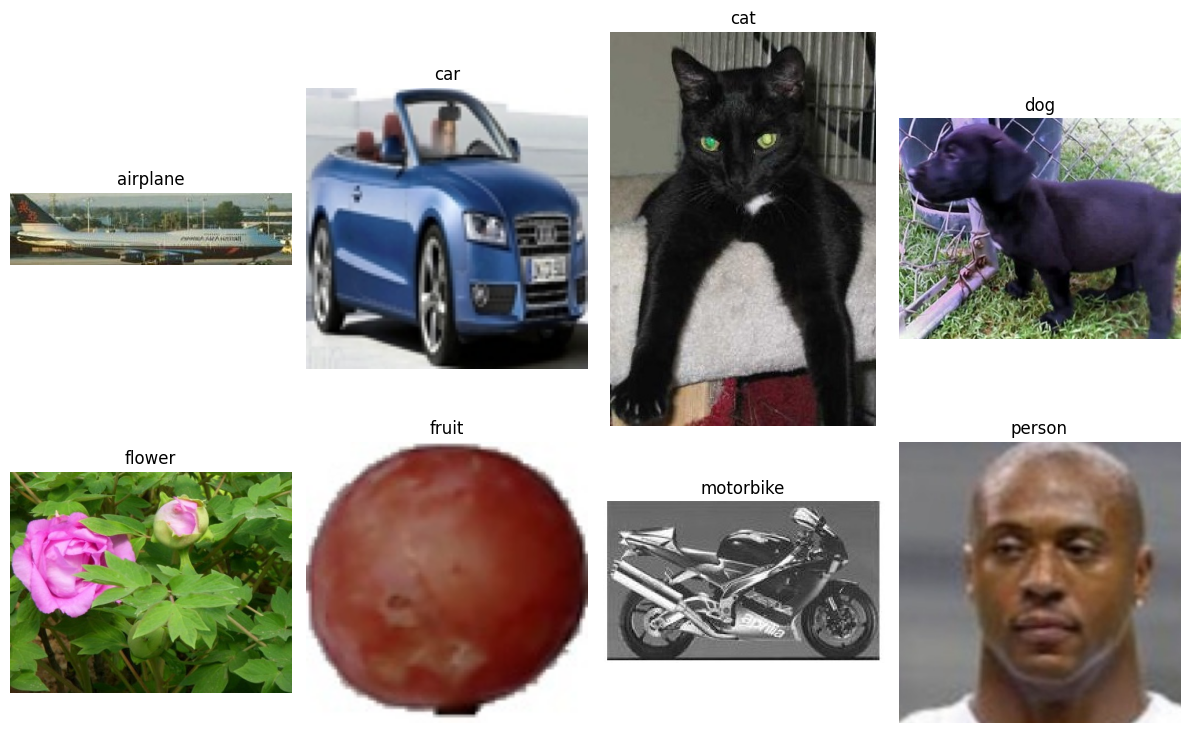

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_dir, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 6899 files belonging to 8 classes.
Using 5520 files for training.
Found 6899 files belonging to 8 classes.
Using 1379 files for validation.


In [7]:
class_names = train_ds.class_names

print("Class names:", class_names)

Class names: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']


In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

# designing the CNN architecture

In [10]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(8, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,568 (12.61 MB)

 Trainable params: 3,306,120 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.5701 - loss: 1.7332 - val_accuracy: 0.2719 - val_loss: 5.6808
Epoch 2/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.6571 - loss: 1.1046 - val_accuracy: 0.6106 - val_loss: 1.2976
Epoch 3/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.6991 - loss: 0.9102 - val_accuracy: 0.7919 - val_loss: 0.5843
Epoch 4/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.7301 - loss: 0.7888 - val_accuracy: 0.8049 - val_loss: 0.5531
Epoch 5/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.7426 - loss: 0.7271 - val_accuracy: 0.7868 - val_loss: 0.8364
Epoch 6/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.7719 - loss: 0.6514 - val_accuracy: 0.7397 - val_loss: 0.8252
Epoch 7/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.7716 - loss: 0.6389 - val_accuracy: 0.8441 - val_loss: 0.4974
Epoch 8/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.7984 - loss: 0.6099 - val_accu

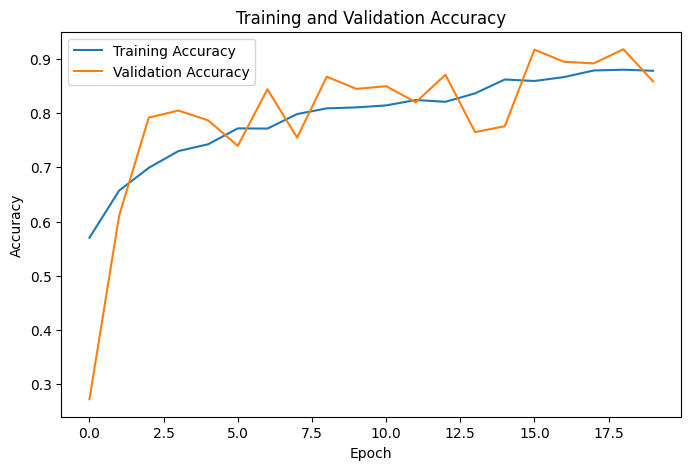

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

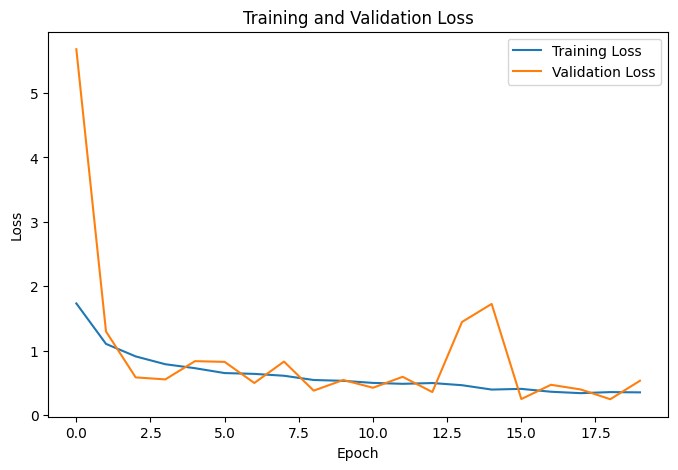

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.74      1.00      0.85       125
         car       0.92      0.98      0.95       184
         cat       0.81      0.54      0.65       173
         dog       0.82      0.43      0.56       159
      flower       0.65      0.99      0.79       169
       fruit       0.98      1.00      0.99       205
   motorbike       0.97      0.90      0.94       165
      person       0.99      0.98      0.98       199

    accuracy                           0.86      1379
   macro avg       0.86      0.85      0.84      1379
weighted avg       0.87      0.86      0.85      1379



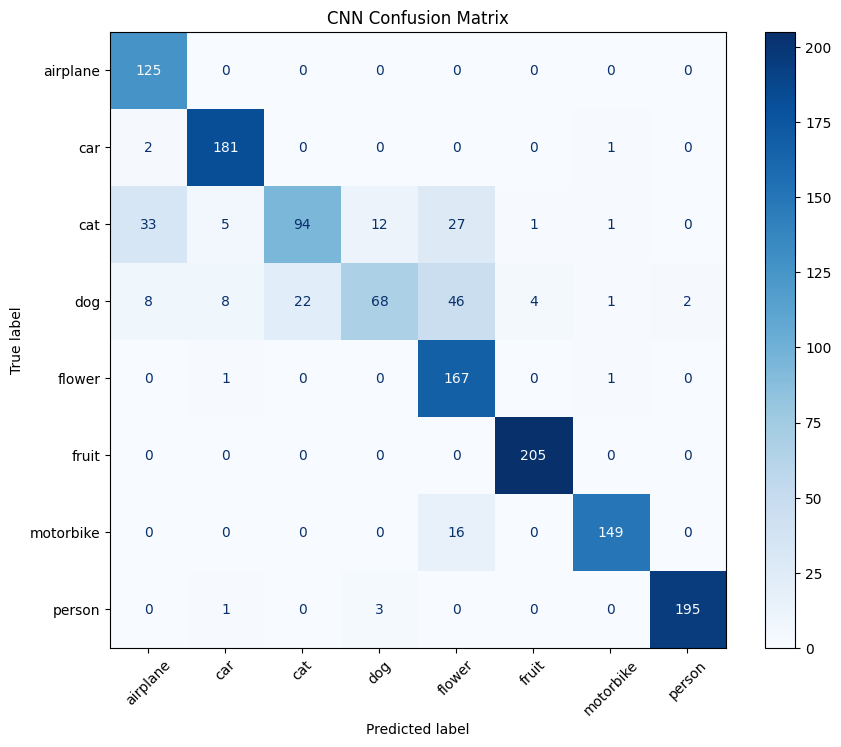

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("CNN Confusion Matrix")
plt.show()

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [18]:
history_opt = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.8793 - loss: 0.3386 - val_accuracy: 0.8666 - val_loss: 0.7329 - learning_rate: 0.0010
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.8851 - loss: 0.3507 - val_accuracy: 0.6672 - val_loss: 2.7084 - learning_rate: 0.0010
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.8846 - loss: 0.3311 - val_accuracy: 0.9123 - val_loss: 0.2948 - learning_rate: 0.0010
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.8861 - loss: 0.3522 - val_accuracy: 0.9152 - val_loss: 0.2628 - learning_rate: 0.0010
Epoch 5/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.8911 - loss: 0.3103 - val_accuracy: 0.7288 - val_loss: 1.1883 - learning_rate: 0.0010
Epoch 6/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8832 - loss: 0.3335 - val_accuracy: 0.9101 - val_loss: 0.3542 - learning_rate: 0.0010
Epoch 7/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.9047 - loss: 0.